In [1]:
import sys

import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)

3.12.6 2.0.2 2.3.3 1.6.1


# Part 1. Entropy and information gain by hand

Notation: $H = -\sum_c p_c \log_2 p_c$ and
$IG = H(\text{parent}) - \sum_{k} \frac{n_k}{n} H(\text{child}_k)$.

   SEED = 421 (last 4 digits of my student ID: 0421)

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 421 

data = pd.read_csv("data/heart_disease.csv")
feature_names = [c for c in data.columns if c != "disease"]
X, y = data[feature_names].to_numpy(), data["disease"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)

(297, 14) 0.461 (207, 13) (90, 13)


In [3]:
toy = pd.DataFrame({
    "age_55_plus": [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
    "exercise_angina": [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "male": [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "high_bp": [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
    "disease": [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})
toy

,age_55_plus,exercise_angina,male,high_bp,disease
0,1,1,1,1,1
1,1,1,1,1,1
2,1,1,1,0,1
3,1,1,0,1,1
4,1,0,0,1,1
5,0,0,0,0,1
6,1,0,1,0,0
7,0,0,1,0,0
8,0,0,1,0,0
9,0,0,0,1,0


H = -(6/12 · log2(6/12) + 6/12 · log2(6/12)) = -(0.5·(-1) + 0.5·(-1)) = 1

### Gain for `age_55_plus`

| group | patients | sick | healthy | entropy |
|---|---|---|---|---|
| age_55_plus = 1 | 6 | 5 | 1 | 0.650 |
| age_55_plus = 0 | 6 | 1 | 5 | 0.650 |

$$H_1 = -\left(\tfrac{5}{6}\log_2\tfrac{5}{6} + \tfrac{1}{6}\log_2\tfrac{1}{6}\right) = -(0.8333\cdot(-0.2630) + 0.1667\cdot(-2.5850)) = 0.650$$

$$H_0 = -\left(\tfrac{1}{6}\log_2\tfrac{1}{6} + \tfrac{5}{6}\log_2\tfrac{5}{6}\right) = 0.650$$

$$\text{weighted} = \tfrac{6}{12}\cdot 0.650 + \tfrac{6}{12}\cdot 0.650 = 0.650$$

$$\text{Gain} = 1 - 0.650 = \mathbf{0.350}$$

In [4]:
import math
H_parent = -(0.5 * math.log2(0.5) + 0.5 * math.log2(0.5))
print(H_parent)

1.0


In [5]:
def H(*counts):
    n = sum(counts)
    return -sum((c / n) * math.log2(c / n) for c in counts if c > 0)

print(pd.crosstab(toy["age_55_plus"], toy["disease"]))
gain_age = 1 - (6/12 * H(5, 1) + 6/12 * H(1, 5))
print(gain_age)

disease      0  1
age_55_plus      
0            5  1
1            1  5
0.3499775783516459



**age_55_plus**
- = 1: p1–p5 sick, p7 healthy → 6 patients, (5 sick, 1 healthy)
- = 0: p6 sick, p8–p12 healthy → 6 patients, (1 sick, 5 healthy)

$$H_1 = -\left(\tfrac56\log_2\tfrac56+\tfrac16\log_2\tfrac16\right) = -(0.8333\cdot(-0.2630)+0.1667\cdot(-2.5850)) = 0.6500,\qquad H_0 = 0.6500$$
$$IG = 1 - \left(\tfrac{6}{12}\cdot0.6500+\tfrac{6}{12}\cdot0.6500\right) = 1 - 0.6500 = \mathbf{0.3500}$$

**exercise_angina**
- = 1: p1–p4, all sick → 4 patients, (4 sick, 0 healthy), $H = 0$
- = 0: p5, p6 sick; p7–p12 healthy → 8 patients, (2 sick, 6 healthy)

$$H_0 = -\left(\tfrac28\log_2\tfrac28+\tfrac68\log_2\tfrac68\right) = -(0.25\cdot(-2)+0.75\cdot(-0.4150)) = 0.8113$$
$$IG = 1 - \left(\tfrac{4}{12}\cdot0+\tfrac{8}{12}\cdot0.8113\right) = 1 - 0.5409 = \mathbf{0.4591}$$

**male**
- = 1: p1, p2, p3 sick; p7, p8, p9 healthy → 6 patients, (3 sick, 3 healthy), $H = 1$
- = 0: p4, p5, p6 sick; p10, p11, p12 healthy → 6 patients, (3 sick, 3 healthy), $H = 1$

$$IG = 1 - \left(\tfrac{6}{12}\cdot1+\tfrac{6}{12}\cdot1\right) = 1 - 1 = \mathbf{0.0000}$$

**high_bp**
- = 1: p1, p2, p4, p5 sick; p10, p11 healthy → 6 patients, (4 sick, 2 healthy)
- = 0: p3, p6 sick; p7, p8, p9, p12 healthy → 6 patients, (2 sick, 4 healthy)

$$H_1 = -\left(\tfrac46\log_2\tfrac46+\tfrac26\log_2\tfrac26\right) = -(0.6667\cdot(-0.5850)+0.3333\cdot(-1.5850)) = 0.9183,\qquad H_0 = 0.9183$$
$$IG = 1 - \left(\tfrac{6}{12}\cdot0.9183+\tfrac{6}{12}\cdot0.9183\right) = 1 - 0.9183 = \mathbf{0.0817}$$

In [6]:
import math

def H(*counts):
    """Entropy in bits of a group given class counts."""
    n = sum(counts)
    return -sum((c / n) * math.log2(c / n) for c in counts if c > 0)

H_parent = H(6, 6)
print("H_parent =", H_parent)
for f in ["age_55_plus", "exercise_angina", "male", "high_bp"]:
    print(f)
    print(pd.crosstab(toy[f], toy["disease"]), "\n")
gain_age = H_parent - (6/12 * H(5, 1) + 6/12 * H(1, 5))
gain_angina = H_parent - (8/12 * H(6, 2) + 4/12 * H(0, 4))
gain_male = H_parent - (6/12 * H(3, 3) + 6/12 * H(3, 3))
gain_bp = H_parent - (6/12 * H(4, 2) + 6/12 * H(2, 4))

print("gain age_55_plus    =", round(gain_age, 4))
print("gain exercise_angina =", round(gain_angina, 4))
print("gain male            =", round(gain_male, 4))
print("gain high_bp         =", round(gain_bp, 4))

H_parent = 1.0
age_55_plus
disease      0  1
age_55_plus      
0            5  1
1            1  5 

exercise_angina
disease          0  1
exercise_angina      
0                6  2
1                0  4 

male
disease  0  1
male         
0        3  3
1        3  3 

high_bp
disease  0  1
high_bp      
0        4  2
1        2  4 

gain age_55_plus    = 0.35
gain exercise_angina = 0.4591
gain male            = 0.0
gain high_bp         = 0.0817



Patients p5–p12: 2 sick (p5, p6), 6 healthy. $H_{sub} = -\left(\tfrac28\log_2\tfrac28+\tfrac68\log_2\tfrac68\right) = 0.8113$.

**age_55_plus**
- = 1: p5 sick, p7 healthy → 2 patients (1, 1), $H = 1$
- = 0: p6 sick; p8–p12 healthy → 6 patients (1 sick, 5 healthy), $H = 0.6500$

$$IG = 0.8113 - \left(\tfrac28\cdot1+\tfrac68\cdot0.6500\right) = 0.8113 - 0.7375 = \mathbf{0.0738}$$

**male**
- = 1: p7, p8, p9, all healthy → 3 patients (0, 3), $H = 0$
- = 0: p5, p6 sick; p10, p11, p12 healthy → 5 patients (2 sick, 3 healthy), $H = -\left(\tfrac25\log_2\tfrac25+\tfrac35\log_2\tfrac35\right) = 0.9710$

$$IG = 0.8113 - \left(\tfrac38\cdot0+\tfrac58\cdot0.9710\right) = 0.8113 - 0.6069 = \mathbf{0.2044}$$

**high_bp**
- = 1: p5 sick; p10, p11 healthy → 3 patients (1, 2), $H = 0.9183$
- = 0: p6 sick; p7, p8, p9, p12 healthy → 5 patients (1, 4), $H = 0.7219$

$$IG = 0.8113 - \left(\tfrac38\cdot0.9183+\tfrac58\cdot0.7219\right) = 0.8113 - 0.7956 = \mathbf{0.0157}$$

In [7]:
sub = toy[toy["exercise_angina"] == 0]
print(sub, "\n")

H_sub = H(6, 2)  
print("H_sub =", round(H_sub, 4))

for f in ["age_55_plus", "male", "high_bp"]:
    print(f)
    print(pd.crosstab(sub[f], sub["disease"]), "\n")
gain_age_sub = H_sub - (6/8 * H(5, 1) + 2/8 * H(1, 1))
gain_male_sub = H_sub - (5/8 * H(3, 2) + 3/8 * H(3, 0))
gain_bp_sub = H_sub - (5/8 * H(4, 1) + 3/8 * H(2, 1))

print("gain age_55_plus =", round(gain_age_sub, 4))
print("gain male        =", round(gain_male_sub, 4))
print("gain high_bp     =", round(gain_bp_sub, 4))

    age_55_plus  exercise_angina  male  high_bp  disease
4             1                0     0        1        1
5             0                0     0        0        1
6             1                0     1        0        0
7             0                0     1        0        0
8             0                0     1        0        0
9             0                0     0        1        0
10            0                0     0        1        0
11            0                0     0        0        0 

H_sub = 0.8113
age_55_plus
disease      0  1
age_55_plus      
0            5  1
1            1  1 

male
disease  0  1
male         
0        3  2
1        3  0 

high_bp
disease  0  1
high_bp      
0        4  1
1        2  1 

gain age_55_plus = 0.0738
gain male        = 0.2044
gain high_bp     = 0.0157


In [8]:
def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    p = np.bincount(y) / len(y)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


def information_gain(y, left):
    """Entropy of y minus the size-weighted entropy of y[left] and y[~left]; left is a boolean mask."""
    n = len(y)
    n_left = int(left.sum())
    n_right = n - n_left
    return entropy(y) - (n_left / n) * entropy(y[left]) - (n_right / n) * entropy(y[~left])


def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain) of the best split, or None if no valid split exists."""
    best = None
    for j in range(X.shape[1]):
        values = np.unique(X[:, j])
        for t in (values[:-1] + values[1:]) / 2:      # midpoints between consecutive distinct values
            left = X[:, j] <= t
            n_left = int(left.sum())
            if n_left < min_samples_leaf or len(y) - n_left < min_samples_leaf:
                continue
            g = information_gain(y, left)
            if best is None or g > best[2]:           # strict ">" keeps lower feature / lower threshold on ties
                best = (j, float(t), g)
    return best


def majority(y):
    """Majority class; a tie goes to the smaller label."""
    return int(np.bincount(y).argmax())


def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Grow a tree recursively and return it as nested dicts (or any structure you like)."""
    if len(np.unique(y)) == 1 or (max_depth is not None and depth == max_depth):
        return {"leaf": majority(y)}
    split = best_split(X, y, min_samples_leaf)
    if split is None:
        return {"leaf": majority(y)}
    j, t, _ = split
    left = X[:, j] <= t
    return {"feature": j, "threshold": t,
            "left": build_tree(X[left], y[left], max_depth, min_samples_leaf, depth + 1),
            "right": build_tree(X[~left], y[~left], max_depth, min_samples_leaf, depth + 1)}


def predict_tree(tree, X):
    """Return one predicted label per row of X."""
    out = np.empty(len(X), dtype=int)
    for i, row in enumerate(X):
        node = tree
        while "leaf" not in node:
            node = node["left"] if row[node["feature"]] <= node["threshold"] else node["right"]
        out[i] = node["leaf"]
    return out

# Part 2: Decision tree from scratch

I implement the learning algorithm in NumPy with the required signatures:
`entropy`, `information_gain`, `best_split`, `build_tree`, `predict_tree`.

$$H(y) = -\sum_c p_c \log_2 p_c \qquad IG = H(y) - \tfrac{n_L}{n}H(y_L) - \tfrac{n_R}{n}H(y_R)$$

In [9]:
y_toy = toy["disease"].to_numpy()
print("entropy:", entropy(y_toy))   # ожидается 1.0
for f in ["age_55_plus", "exercise_angina", "male", "high_bp"]:
    left = toy[f].to_numpy() == 0
    print(f, round(information_gain(y_toy, left), 4))

entropy: 1.0
age_55_plus 0.35
exercise_angina 0.4591
male 0.0
high_bp 0.0817


In [10]:
from sklearn.tree import DecisionTreeClassifier

ref = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=SEED).fit(X_train, y_train)
print("sklearn:", feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

j, t, g = best_split(X_train, y_train)
print("mine:   ", feature_names[j], t, "gain =", round(g, 4))

sklearn: thal 4.5
mine:    thal 4.5 gain = 0.1897


In [11]:
rows = []
for d in [1, 2, 3, 4, 5, None]:
    mine = build_tree(X_train, y_train, max_depth=d)
    sk = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(X_train, y_train)
    agree = (predict_tree(mine, X_test) == sk.predict(X_test)).mean()
    rows.append({"max_depth": "unlimited" if d is None else d, "agreement": round(agree, 4)})
pd.DataFrame(rows)

,max_depth,agreement
0,1,1.0000
1,2,1.0000
2,3,1.0000
3,4,1.0000
4,5,1.0000
5,unlimited,0.9667


 # Part 3: How deep should the tree be?

In [12]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def sweep(param, values):
    rows = []
    for v in values:
        kw = {"max_depth": v} if param == "max_depth" else {"max_depth": None, "min_samples_leaf": v}
        model = DecisionTreeClassifier(criterion="entropy", random_state=SEED, **kw)
        s = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
        leaves = model.fit(X_train, y_train).get_n_leaves()   # число листьев: дерево на всём train
        rows.append({param: "unlimited" if v is None else v, "leaves": leaves,
                     "train_acc": s["train_score"].mean(), "cv_acc": s["test_score"].mean(),
                     "cv_std": s["test_score"].std()})
    return pd.DataFrame(rows)

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
depth_table = sweep("max_depth", depths)
depth_table.round(4)

,max_depth,leaves,train_acc,cv_acc,cv_std
0,1,2,0.7596,0.6856,0.0776
1,2,4,0.7826,0.6993,0.1027
2,3,8,0.8430,0.7052,0.0585
3,4,15,0.8913,0.7196,0.0783
4,5,23,0.9251,0.7052,0.0646
5,6,28,0.9577,0.7293,0.0798
6,8,33,0.9891,0.6957,0.0713
7,10,35,0.9976,0.7099,0.0628
8,unlimited,35,1.0000,0.7242,0.0746


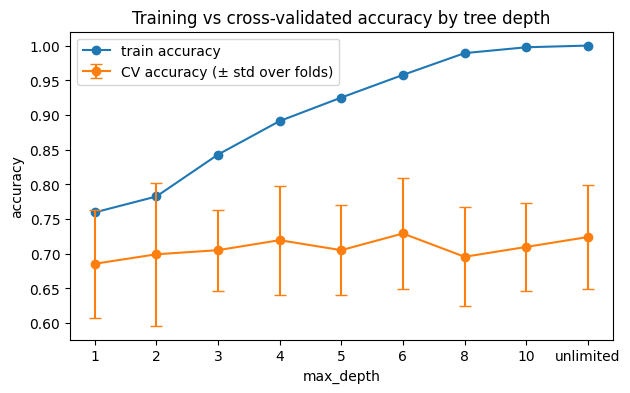

In [13]:
x = range(len(depth_table))
plt.figure(figsize=(7, 4))
plt.plot(x, depth_table["train_acc"], marker="o", label="train accuracy")
plt.errorbar(x, depth_table["cv_acc"], yerr=depth_table["cv_std"], marker="o", capsize=4, label="CV accuracy (± std over folds)")
plt.xticks(x, depth_table["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Training vs cross-validated accuracy by tree depth")
plt.legend()
plt.show()

In [14]:
best = depth_table["cv_acc"].idxmax()
threshold = depth_table.loc[best, "cv_acc"] - depth_table.loc[best, "cv_std"]
candidates = depth_table[depth_table["cv_acc"] >= threshold]
chosen = candidates.sort_values("leaves").iloc[0]
chosen_depth = chosen["max_depth"]
chosen_depth = None if chosen_depth == "unlimited" else int(chosen_depth)

print("best mean CV depth:", depth_table.loc[best, "max_depth"], "| threshold:", round(threshold, 4))
print("chosen depth:", chosen_depth)

best mean CV depth: 6 | threshold: 0.6494
chosen depth: 1


In [15]:
leaf_table = sweep("min_samples_leaf", [1, 2, 5, 10, 20, 40])
leaf_table.round(4)

,min_samples_leaf,leaves,train_acc,cv_acc,cv_std
0,1,35,1.0000,0.7242,0.0746
1,2,33,0.9626,0.6859,0.0404
2,5,20,0.8973,0.7148,0.0544
3,10,11,0.8503,0.7099,0.0773
4,20,6,0.7947,0.7095,0.0785
5,40,4,0.7596,0.6856,0.0776


In [16]:
final = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED).fit(X_train, y_train)
p = final.score(X_test, y_test)
n = len(y_test)
se = np.sqrt(p * (1 - p) / n)
print(f"test accuracy = {p:.4f}, standard error = {se:.4f}, n = {n}")

test accuracy = 0.7889, standard error = 0.0430, n = 90


# Part 4: Tree or logistic regression?

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

models = {
    f"tree (max_depth={chosen_depth})": DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED),
    "tree (unlimited)": DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=SEED),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
}

rows = []
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=("accuracy", "f1"))
    rows.append({"model": name,
                 "cv_acc_mean": s["test_accuracy"].mean(), "cv_acc_std": s["test_accuracy"].std(),
                 "cv_f1_mean": s["test_f1"].mean()})
pd.DataFrame(rows).round(4)

,model,cv_acc_mean,cv_acc_std,cv_f1_mean
0,tree (max_depth=1),0.6856,0.0776,0.6600
1,tree (unlimited),0.7242,0.0746,0.6765
2,logistic regression,0.8452,0.0651,0.8257


In [18]:
pred_raw = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED) \
    .fit(X_train, y_train).predict(X_test)

scaler = StandardScaler().fit(X_train)
pred_scaled = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED) \
    .fit(scaler.transform(X_train), y_train).predict(scaler.transform(X_test))

print("fraction of identical test predictions:", (pred_raw == pred_scaled).mean())

fraction of identical test predictions: 1.0


In [19]:
tree_final = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED).fit(X_train, y_train)
logreg_final = models["logistic regression"].fit(X_train, y_train)

n = len(y_test)
for name, m in [("tree", tree_final), ("logistic regression", logreg_final)]:
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    se = np.sqrt(acc * (1 - acc) / n)
    print(f"{name}: accuracy = {acc:.4f} (SE {se:.4f}), F1 = {f1_score(y_test, pred):.4f}")
    print(confusion_matrix(y_test, pred), "\n")

tree: accuracy = 0.7889 (SE 0.0430), F1 = 0.7816
[[37 11]
 [ 8 34]] 

logistic regression: accuracy = 0.8000 (SE 0.0422), F1 = 0.7750
[[41  7]
 [11 31]] 



# Part 5: Reading a tree, and reproducibility

In [20]:
from sklearn.tree import export_text

shallow = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(X_train, y_train)
print(export_text(shallow, feature_names=feature_names))

ranked = sorted(zip(shallow.feature_importances_, feature_names), reverse=True)
print([(name, round(float(imp), 3)) for imp, name in ranked[:5]])

|--- thal <= 4.50
|   |--- ca <= 0.50
|   |   |--- thalach <= 160.50
|   |   |   |--- class: 0
|   |   |--- thalach >  160.50
|   |   |   |--- class: 0
|   |--- ca >  0.50
|   |   |--- cp <= 3.50
|   |   |   |--- class: 0
|   |   |--- cp >  3.50
|   |   |   |--- class: 1
|--- thal >  4.50
|   |--- oldpeak <= 0.70
|   |   |--- chol <= 237.00
|   |   |   |--- class: 0
|   |   |--- chol >  237.00
|   |   |   |--- class: 1
|   |--- oldpeak >  0.70
|   |   |--- thalach <= 175.50
|   |   |   |--- class: 1
|   |   |--- thalach >  175.50
|   |   |   |--- class: 0

[('thal', 0.379), ('thalach', 0.179), ('ca', 0.161), ('oldpeak', 0.102), ('cp', 0.096)]


In [21]:
t = shallow.tree_
for i in range(t.node_count):
    if t.children_left[i] == -1:   # лист
        print(f"leaf {i}: {t.n_node_samples[i]} patients, predicts class {shallow.classes_[t.value[i].argmax()]}")
    

leaf 3: 36 patients, predicts class 0
leaf 4: 45 patients, predicts class 0
leaf 6: 20 patients, predicts class 0
leaf 7: 18 patients, predicts class 1
leaf 10: 17 patients, predicts class 0
leaf 11: 13 patients, predicts class 1
leaf 13: 54 patients, predicts class 1
leaf 14: 4 patients, predicts class 0
